In [1]:
import numpy as np
import cv2 #to work with images
from skimage.measure import label, regionprops_table #to get shape properties
import pandas as pd #make spreadsheet
from scipy import ndimage as ndi #for watershed segmentation
from skimage.feature import peak_local_max #for watershed segmentation
from skimage.segmentation import watershed #for watershed segmentation
import os
import matplotlib.pyplot as plt
from skimage.color import label2rgb

In [2]:
def get_labels(img):
    distance = ndi.distance_transform_edt(img)
    local_max_coords = peak_local_max(distance, min_distance=50)
    local_max_mask = np.zeros(distance.shape, dtype=bool)
    local_max_mask[tuple(local_max_coords.T)] = True
    markers = label(local_max_mask)
    segmented_cells = watershed(-distance, markers, mask=img)
    return segmented_cells

In [3]:
def get_axon_row(axon_df, left, right, top, bottom):
    '''
    Using the myelin bounding box find the larges axon that correspons to that myelin
    '''
    
    left = int(left)
    right = int(right)
    top = int(top)
    bottom = int(bottom)
    
    axons_id = axon_df[(((axon_df['centroid-0'])>=left) & (axon_df['centroid-0']<=right)) &
                       ((axon_df['centroid-1'])>=top) & (axon_df['centroid-1']<=bottom)]
    biggest_axon = axons_id[axons_id['area'] == axons_id['area'].max()]
    
    return biggest_axon


In [4]:
def get_morphometrics(img_path):
    '''
    Get morphometric data from a single image and return a pandas df of the morphometric data
    
    :param img_path: A path (string or object) pointing to a single segmented image in which the myelin is a middle grey and the axon is white
    
    :returns: Pandas DataFrame; morphometrics
    '''
    
    #read the image and flatten it into black and white
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    axon = cv2.inRange(img, 200, 255) #axons are everything above a medium gray
    myelin = cv2.inRange(img, 1, 255) #myelin is actually axon+myelin so everything above black
    
    #watershed labelling of axons then obtaining region properties and putting it in a DataFrame
    axon_label = get_labels(axon)
    axon_props = regionprops_table(axon_label,properties=('label', 'centroid', 'area', 'axis_minor_length', 'axis_major_length', 
                                                          'eccentricity', 'orientation', 'perimeter', 'solidity'))
    axon_df = pd.DataFrame.from_dict(axon_props)

    #watershed labelling of myelin then obtaining region properties and putting it in a DataFrame
    myelin_label = get_labels(myelin)
    myelin_props = regionprops_table(myelin_label, properties=('label', 'bbox', 'area', 'axis_minor_length', 'axis_major_length',
                                                               'perimeter'))
    myelin_df = pd.DataFrame.from_dict(myelin_props)
    
    #making an empty DataFrame to put morphometric data into
    columns = {'label':[],
               'x':[],
               'y':[],
               'axon_area':[],
               'axon_perimeter':[],
               'axon_diam':[],
               'myelin_area':[],
               'myelin_thickness':[],
               'myelin_perimeter':[],
               'eccentricity':[],
               'orientation':[],
               'solidity':[],
               'gratio':[]}
    morph_df1 = pd.DataFrame(columns)
    morph_df2 = pd.DataFrame(columns)
    
    #going through all the myelin that got accounted for in watershed
    #using myelin to compare to axons
    drop_rows = []    
    for index, row in myelin_df.iterrows():
        left = row['bbox-0']
        right = row['bbox-2']
        top = row['bbox-1']
        bottom = row['bbox-3']
        
        axon_row = get_axon_row(axon_df, left, right, top, bottom)
        if not(axon_row.empty):
            label = row['label']
            x = axon_row['centroid-0']
            y = axon_row['centroid-1']
            axon_area = axon_row['area']
            axon_perimeter = axon_row['perimeter']
            axon_diam = axon_row['axis_major_length']#(row['axis_major_length'] + row['axis_minor_length']) / 2 #getting axon diameter along the major axis
            eccentricity = axon_row['eccentricity']
            orientation = axon_row['orientation']
            solidity = axon_row['solidity']
            
            myelin_area = row['area'] - axon_area
            myelin_thickness = row['axis_major_length']
            myelin_perimeter = row['perimeter']
            gratio = axon_diam / row['axis_major_length']
            
            if gratio.iloc[0] < 1:
                #make a one row DataFrame with axon and myelin data
                new_dict = {'label':label,
                        'x':x,
                        'y':y,
                        'axon_area':axon_area,
                        'axon_perimeter':axon_perimeter,
                        'axon_diam':axon_diam,
                        'myelin_area':myelin_area,
                        'myelin_thickness':myelin_thickness,
                        'myelin_perimeter':myelin_perimeter,
                        'eccentricity':eccentricity,
                        'orientation':orientation,
                        'solidity':solidity,
                        'gratio':gratio}

                new_df = pd.DataFrame(new_dict)
                
                #add the new data to the morphometrics DataFrame
                morph_df2 = pd.concat([morph_df2,new_df], ignore_index=True)
        
    morph_df2 = morph_df2.drop(drop_rows)
    return axon_label, myelin_label, morph_df2

In [5]:
axons, myelin, df = get_morphometrics(r"T:\Orthopaedics\Lab Imaging Data\plamothe\Colorado Study\Colorado study ARCHIVE\DA Test\P1503\CMNProx\40x_segment\P1503_40X_CMNProx_001.tif")
df

,label,x,y,axon_area,axon_perimeter,axon_diam,myelin_area,myelin_thickness,myelin_perimeter,eccentricity,orientation,solidity,gratio
0,2.0,94.236842,1063.609023,266.0,96.870058,41.228279,1278.0,90.525967,292.551299,0.975046,-1.368802,0.798799,0.455430
1,4.0,95.456660,2135.809725,473.0,118.734019,49.299499,3315.0,177.055898,541.611219,0.960498,-1.492742,0.824042,0.278440
2,6.0,128.956522,1771.555901,322.0,86.041631,40.402566,1430.0,80.515610,200.953319,0.964430,-1.455857,0.887052,0.501798
3,8.0,156.696562,1626.052317,669.0,129.882251,56.033044,3624.0,116.283937,288.350288,0.957778,-1.130073,0.908967,0.481864
4,9.0,162.149457,268.521739,368.0,146.189863,65.243266,2391.0,114.821948,295.616270,0.984638,-1.308754,0.637782,0.568213
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,200.0,1891.688502,1302.673171,4305.0,248.450793,81.747842,12568.0,216.428589,992.589971,0.566438,0.590220,0.971126,0.377713
174,201.0,1901.112006,2065.393971,3848.0,377.060967,109.087088,5893.0,148.557997,631.748304,0.842929,-1.354842,0.700655,0.734306
175,202.0,1911.973189,1628.775635,4252.0,265.663997,78.229474,13486.0,227.863443,719.612265,0.415075,0.379870,0.937596,0.343317
176,203.0,1914.810707,1491.562415,8051.0,362.617316,120.211187,9300.0,175.718930,740.488419,0.689275,-0.872536,0.946063,0.684111


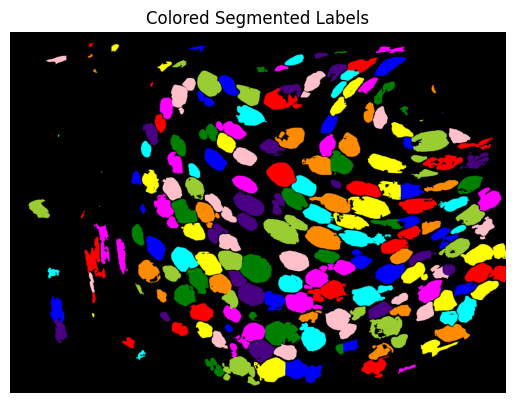

In [6]:
# Convert labels to RGB image with unique colors
colored_labels = label2rgb(myelin, bg_label=0)

# Display
plt.imshow(colored_labels)
plt.title("Colored Segmented Labels")
plt.axis('off')
plt.show()

In [7]:
df

,label,x,y,axon_area,axon_perimeter,axon_diam,myelin_area,myelin_thickness,myelin_perimeter,eccentricity,orientation,solidity,gratio
0,2.0,94.236842,1063.609023,266.0,96.870058,41.228279,1278.0,90.525967,292.551299,0.975046,-1.368802,0.798799,0.455430
1,4.0,95.456660,2135.809725,473.0,118.734019,49.299499,3315.0,177.055898,541.611219,0.960498,-1.492742,0.824042,0.278440
2,6.0,128.956522,1771.555901,322.0,86.041631,40.402566,1430.0,80.515610,200.953319,0.964430,-1.455857,0.887052,0.501798
3,8.0,156.696562,1626.052317,669.0,129.882251,56.033044,3624.0,116.283937,288.350288,0.957778,-1.130073,0.908967,0.481864
4,9.0,162.149457,268.521739,368.0,146.189863,65.243266,2391.0,114.821948,295.616270,0.984638,-1.308754,0.637782,0.568213
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,200.0,1891.688502,1302.673171,4305.0,248.450793,81.747842,12568.0,216.428589,992.589971,0.566438,0.590220,0.971126,0.377713
174,201.0,1901.112006,2065.393971,3848.0,377.060967,109.087088,5893.0,148.557997,631.748304,0.842929,-1.354842,0.700655,0.734306
175,202.0,1911.973189,1628.775635,4252.0,265.663997,78.229474,13486.0,227.863443,719.612265,0.415075,0.379870,0.937596,0.343317
176,203.0,1914.810707,1491.562415,8051.0,362.617316,120.211187,9300.0,175.718930,740.488419,0.689275,-0.872536,0.946063,0.684111


In [8]:
df['axon_diam'].mean() 

87.48983621528443